PyTorch Neural Network Classification

Example of Toy Problem as practice: "a problem that's used to try & test things out" with binary cross entropy & SGD
Note: lr typically at 0.001 to be safe but 0.01 good start point

Classification Problem:
- Binary Classification: predict 1 of 2 options
- Multi-Class Classification: predict 1 of many options
- Multi-Label Classification: target can be more than 1 option

Architecture of Classification NN: Hyperparameters:
- Input Layer Features: #of features
- Hidden Layer(s): 1->unlimited #
- Neurons per Hidden Layer: Generally 10-512
- Output Layer Shape: 1 per class
- Hidden Layer Activation: Func for if activate neuron — Many types ~ common ReLU (Recitified Linear Unit) 0 if negative 1 if positive, others: tanh, etc
- Output Activation: Binary: Sigmoid, Multi-Class: Softmax
- Loss Function: Binary: Binary crossentropy, Multi-Class: cross entropy
- Optimizer: SGD, Adam


In [22]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import torch
import requests
from torch import nn
import numpy as np
from pathlib import Path
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [3]:
numSamples = 1000
x, y = make_circles(numSamples, noise = 0.03, random_state=42)
print(f"x:\n{x[:5]}")
print(f"\ny\n{y[:5]}")

x:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

y
[1 1 1 1 0]


In [4]:
circles = pd.DataFrame({"x1": x[:,0], "x2": x[:,1], "label":y})
circles.head(10), circles.label.value_counts(), x.shape, y.shape

(         x1        x2  label
 0  0.754246  0.231481      1
 1 -0.756159  0.153259      1
 2 -0.815392  0.173282      1
 3 -0.393731  0.692883      1
 4  0.442208 -0.896723      0
 5 -0.479646  0.676435      1
 6 -0.013648  0.803349      1
 7  0.771513  0.147760      1
 8 -0.169322 -0.793456      1
 9 -0.121486  1.021509      0,
 label
 1    500
 0    500
 Name: count, dtype: int64,
 (1000, 2),
 (1000,))

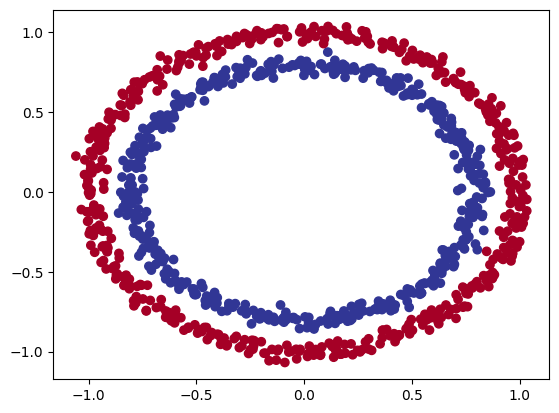

In [5]:
plt.scatter(x=x[:,0], y=x[:,1], c=y, cmap=plt.cm.RdYlBu)

In [6]:
#convert to tensor
xt = torch.from_numpy(x).type(torch.float)
yt = torch.from_numpy(y).type(torch.float)
xtrain, xtest, ytrain, ytest = train_test_split(xt, yt, test_size=0.2, random_state=42)
xtrain[:5], ytrain[:5], xtrain.dtype

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]),
 torch.float32)

This model will have 2 nn layers

In [7]:
class CircleModelPatel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2, out_features=5)
    self.layer2 = nn.Linear(in_features=5, out_features=1)
  def forward(self, x):
    return self.layer2(self.layer1(x))
model1 = CircleModelPatel().to(device)
model1


CircleModelPatel(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

Alternative to Model (sequential only runs sequentially)

In [8]:
model2 = nn.Sequential(nn.Linear(in_features=2, out_features=5), nn.Linear(in_features=5, out_features=1)).to(device)
model2

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [9]:
untrainedPred = model1(xtrain.to(device))
untrainedPred[:5], ytest[:5]

(tensor([[-0.0827],
         [-0.0128],
         [-0.1032],
         [-0.0789],
         [-0.3725]], grad_fn=<SliceBackward0>),
 tensor([1., 0., 1., 0., 1.]))

Binary cross entropy implementations: torch.nn.BCELoss(), torch.nn.BCEWithLogisticsLoss() same as but with sigmoid layer built in
BCEWithLogisticsLoss() is more numerically stable but in more advanced use cases you want to seperate combination fo sigmoid layer and BCELoss()

In [10]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model1.parameters(), lr=0.1)

Evaluation Metric: Basically how correct your model is (opposite of loss func)

In [11]:
#Accuracy: classification metric (example)
def accuracy(numTrue, numPrediction):
  correct = torch.eq(numTrue, numPrediction).sum().item()
  #torch.eq true if 2 tensors equal
  #.item() turns the tensor to scalar of tensor's dtype
  accuracyy = (correct/len(numPrediction))*100
  return accuracyy

Logit: Output on raw model before any optimization

In [12]:
logitBridget = model1(xtrain.to(device))
logitBridget[:5]

tensor([[-0.0827],
        [-0.0128],
        [-0.1032],
        [-0.0789],
        [-0.3725]], grad_fn=<SliceBackward0>)

Sigmoid Activation Function: Exists in BCEWithLogitsLoss. Sigmoid turns raw logit into something intreperable in this case ie) 0.44 is 44% chance of being classifeid 1. Turns into form of prediction probabilities.
Acutal classification would be prediction labels.

In [13]:
logitBridgetSigmoided = torch.sigmoid(logitBridget)
logitBridgetSigmoided[:5]

tensor([[0.4793],
        [0.4968],
        [0.4742],
        [0.4803],
        [0.4079]], grad_fn=<SliceBackward0>)

In [14]:
predLabel = torch.round(logitBridgetSigmoided)
predLabel[:5]

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<SliceBackward0>)

In [15]:
torch.manual_seed(42)

Training + Testing Loop

In [16]:
#data to device
epochs = 100
xtrain, xtest, ytrain, ytest = xtrain.to(device), xtest.to(device), ytrain.to(device), ytest.to(device)

In [17]:
for epoch in range(epochs):
  model1.train()

  #Forward pass - model will output raw logit -> turn to prediction probabilities -> labels
  ylogits = model1(xtrain).squeeze() #squeeze cuz out_features = 1 so 1 val per sample
  ypred = torch.round(torch.sigmoid(ylogits))

  #Calculate loss/accuracy
  loss = loss_fn(ylogits, ytrain) #no need for sigmoid bc BCEWithLogitLoss
  acc = accuracy(ytrain, ypred)

  #Optimizer zero grad - reseting gradients from backpropogation
  optimizer.zero_grad()

  #Loss backward - computes new gradients
  loss.backward()

  #Optimizer Step - updates weights using the gradients
  optimizer.step()

  # -- Testing --
  model1.eval()
  with torch.inference_mode(): #context manager, turns off model training stuff like gradients so saves memory n speed
    #inference: using trained model to make predictions on new data

    #Forward pass
    testLogits = model1(xtest).squeeze()
    testPreds = torch.round(torch.sigmoid(testLogits))

    #Calculate loss/accuracy
    testLoss = loss_fn(testLogits, ytest)
    testAcc = accuracy(ytest, testPreds)

  #printing test results
  if epoch%10==0:
    print(f"Epoch: {epoch} - Loss: {loss:.5f} - Accuracy: {acc:.1f} - Test Loss: {testLoss:.5f} Test Acc: {testAcc:.1f}")


Epoch: 0 - Loss: 0.70161 - Accuracy: 45.1 - Test Loss: 0.69503 Test Acc: 48.0
Epoch: 10 - Loss: 0.69876 - Accuracy: 46.6 - Test Loss: 0.69274 Test Acc: 51.0
Epoch: 20 - Loss: 0.69715 - Accuracy: 47.4 - Test Loss: 0.69177 Test Acc: 52.0
Epoch: 30 - Loss: 0.69609 - Accuracy: 48.1 - Test Loss: 0.69142 Test Acc: 51.0
Epoch: 40 - Loss: 0.69535 - Accuracy: 47.8 - Test Loss: 0.69136 Test Acc: 50.5
Epoch: 50 - Loss: 0.69480 - Accuracy: 48.2 - Test Loss: 0.69145 Test Acc: 51.0
Epoch: 60 - Loss: 0.69439 - Accuracy: 48.1 - Test Loss: 0.69162 Test Acc: 51.5
Epoch: 70 - Loss: 0.69407 - Accuracy: 47.9 - Test Loss: 0.69183 Test Acc: 52.0
Epoch: 80 - Loss: 0.69383 - Accuracy: 48.0 - Test Loss: 0.69206 Test Acc: 51.0
Epoch: 90 - Loss: 0.69364 - Accuracy: 48.5 - Test Loss: 0.69230 Test Acc: 49.5


Predictions & Evaluation:

In [18]:
#Imported from the git dir

# Plot linear data or training and test and predictions (optional)
def plot_predictions(train_data, train_labels, test_data, test_labels, predictions=None):
    #Plots linear training data and test data and compares predictions.
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        # Plot the predictions in red (predictions were made on the test data)
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    # Show the legend
    plt.legend(prop={"size": 14})

def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    #Plots decision boundaries of model predicting on X in comparison to y. Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())

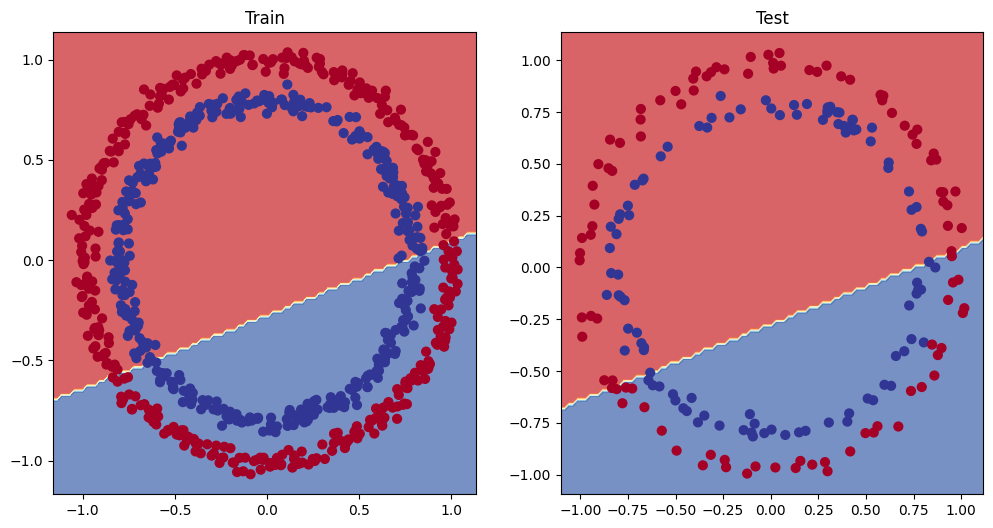

In [23]:
#Also copied bc lazy

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model1, xtrain, ytrain)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model1, xtest, ytest)